# Group Work Project #2: Regime-Based Asset Allocation
## Step 1: Data Preparation and Exploration
This step involves downloading the necessary historical data for our assets (SPY, GLD, TLT) and our regime indicator (VIX). We will then clean and process this data to prepare it for modeling.

### 1.1: Download Historical Data
First, we import the necessary libraries and download the daily price data for all tickers. yfinance now defaults to auto_adjust=True, so we can just use the 'Close' column, which represents the adjusted close price.

We will download the maximum available historical data and then find the common sample period by removing any dates where all four assets did not trade.

In [1]:
#pip install yfinance

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Set plot style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Suppress warnings
warnings.filterwarnings('ignore')

# Define tickers
tickers = ['SPY', 'GLD', 'TLT', '^VIX']

# Define a fixed date range for consistency across assets
start = "2004-01-01"
end = "2025-01-01"

# Download data within the specified date range
raw_data = yf.download(tickers, start=start, end=end)
prices = raw_data['Close'].copy()

# Align data and remove NaNs to find the common sample period
common_data = prices.dropna()

# Rename ^VIX to VIX for easier access
common_data = common_data.rename(columns={'^VIX': 'VIX'})

print(f"Data downloaded. Cleaning NaNs to find common sample period.")
print(f"Original data start: {prices.index.min().date()}")
print(f"Common data start (all assets available): {common_data.index.min().date()}")
print(f"Common data end: {common_data.index.max().date()}")

print("\n--- Cleaned Data Head ---")
print(common_data.head())

[*********************100%***********************]  4 of 4 completed

Data downloaded. Cleaning NaNs to find common sample period.
Original data start: 2004-01-02
Common data start (all assets available): 2004-11-18
Common data end: 2024-12-31

--- Cleaned Data Head ---
Ticker            GLD        SPY        TLT    VIX
Date                                              
2004-11-18  44.380001  80.405945  45.155739  12.98
2004-11-19  44.779999  79.512100  44.795406  13.50
2004-11-22  44.950001  79.891304  45.028847  12.97
2004-11-23  44.750000  80.013168  45.084702  12.67
2004-11-24  45.049999  80.202820  45.084702  12.72


### 1.2: Compute Log-Returns and VIX Changes
As outlined in the course lesson notebooks, our HMM will model the changes in VIX, not its level. For the assets, we will use log-returns, which are standard in financial modeling for their additive properties.

In [2]:
# Create a new DataFrame for returns/changes
returns_df = pd.DataFrame(index=common_data.index)

# Calculate daily log-returns for ETFs
returns_df['SPY_logret'] = np.log(common_data['SPY'] / common_data['SPY'].shift(1))
returns_df['GLD_logret'] = np.log(common_data['GLD'] / common_data['GLD'].shift(1))
returns_df['TLT_logret'] = np.log(common_data['TLT'] / common_data['TLT'].shift(1))

# Calculate the simple change (delta) for VIX, as done in Notebook 20
returns_df['VIX_change'] = common_data['VIX'].diff()

# Drop the first row of NaNs created by .shift() and .diff()
returns_df = returns_df.dropna()

print("Log-Returns and VIX Change (Head):")
print(returns_df.head())

Log-Returns and VIX Change (Head):
            SPY_logret  GLD_logret  TLT_logret  VIX_change
Date                                                      
2004-11-19   -0.011179    0.008973   -0.008012    0.520000
2004-11-22    0.004758    0.003789    0.005198   -0.530000
2004-11-23    0.001524   -0.004459    0.001240   -0.300000
2004-11-24    0.002367    0.006682    0.000000    0.050000
2004-11-26   -0.000760    0.005313   -0.006551    0.059999


### 1.3: Visualize the Data
Now we will create the two required plots to explore the data visually.

#### Plot 1: ETF Daily Log-Returns
This plot helps us observe the volatility clustering and correlations between the assets.

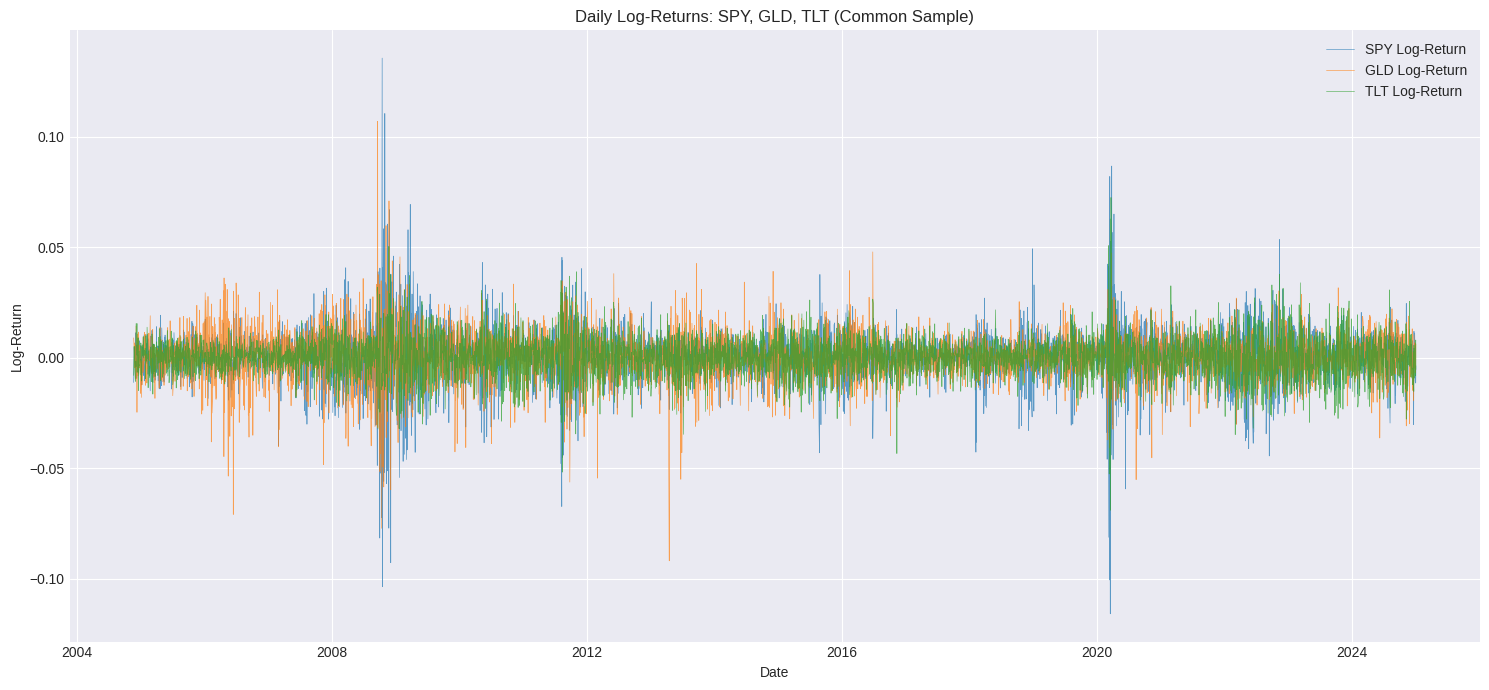

In [3]:
# Plot 1: ETF Returns
plt.figure(figsize=(15, 7))
plt.plot(returns_df.index, returns_df['SPY_logret'], label='SPY Log-Return', alpha=0.7, lw=0.5)
plt.plot(returns_df.index, returns_df['GLD_logret'], label='GLD Log-Return', alpha=0.7, lw=0.5)
plt.plot(returns_df.index, returns_df['TLT_logret'], label='TLT Log-Return', alpha=0.7, lw=0.5)

plt.title('Daily Log-Returns: SPY, GLD, TLT (Common Sample)')
plt.ylabel('Log-Return')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

#### Plot 2: VIX Daily Change (∆VIX)
This plot shows the dynamics of our regime indicator. We can clearly see periods of calm (small changes around zero) and periods of stress (large spikes). This is the behavior our HMM will try to model.

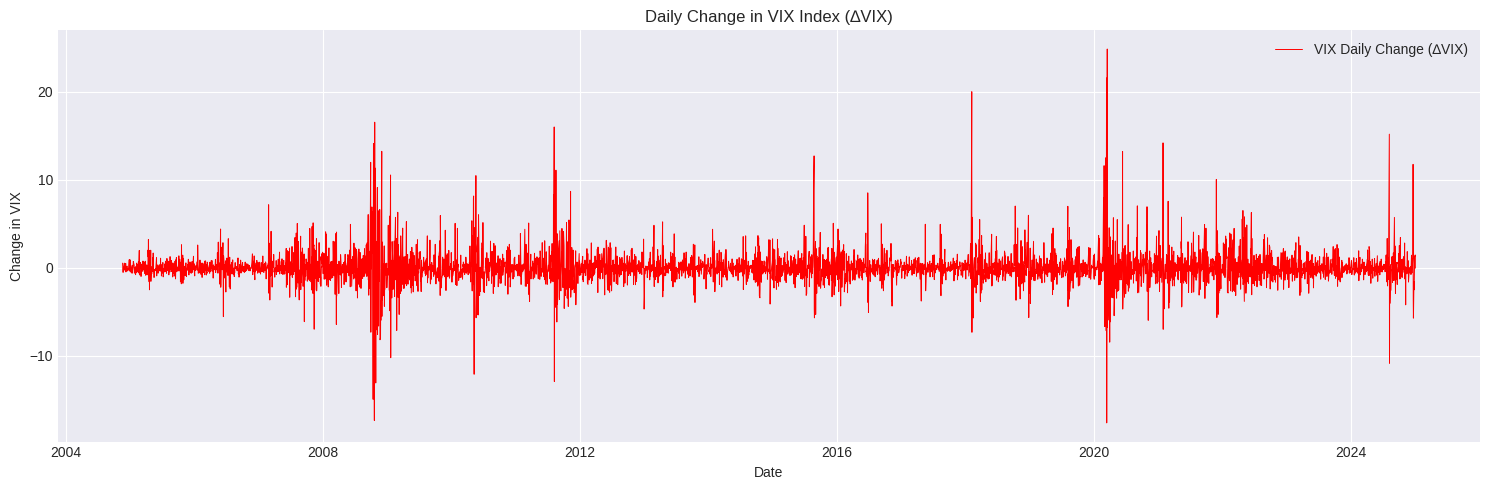

In [4]:
# Plot 2: VIX Changes
plt.figure(figsize=(15, 5))
plt.plot(returns_df.index, returns_df['VIX_change'], label='VIX Daily Change (∆VIX)', color='red', lw=0.7)
plt.title('Daily Change in VIX Index (∆VIX)')
plt.ylabel('Change in VIX')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

## Step 2: Modeling VIX Regimes (HMM Option)

Given the context of the lesson's notebooks (especially from `HMM & EM algorithm and regime switching models`), the Hidden Markov Model (HMM) Option is the most appropriate, as it uses the EM algorithm to infer the hidden regimes rather than imposing them with quantiles.

We will fit both 2-state and 3-state Gaussian Hidden Markov Models (HMMs) to the daily VIX log-returns (y) we calculated in Step 1. The goal is to identify hidden volatility regimes.

### 2.1: Define Generalized HMM Functions

First, we'll generalize the functions from Notebook `EM algorithm and regime switching models` to work for an arbitrary number of states ($N$). This will allow us to fit both 2-state and 3-state models using the same code.

In [5]:
from scipy.optimize import minimize
from scipy.stats import norm

# Store the VIX log-returns from Step 1 in a variable 'y'
y = returns_df['VIX_change'].dropna().values

def emission_prob(y_t, mu_i, sigma_i):
    """Calculates the probability density f(y_t | s_t = i)"""
    return norm.pdf(y_t, loc=mu_i, scale=sigma_i)

def hamilton_filter(y, mu, sigma, P, pi):
    """
    Performs the Hamilton filter for N states.

    y: (T,) observations
    mu: (N,) state means
    sigma: (N,) state std devs
    P: (N, N) transition matrix, P[i, j] = P(s_t = j | s_{t-1} = i)
    pi: (N,) initial probabilities
    """
    T = len(y)
    N = len(mu)

    filtered_probs = np.zeros((T, N))
    predicted_probs = np.zeros((T, N))
    marginal_likelihoods = np.zeros(T)

    # Ensure pi is a valid probability distribution
    predicted_probs[0] = pi / np.sum(pi)

    for t in range(T):
        # 1. Calculate emission densities for all states
        emissions = np.array([emission_prob(y[t], mu[i], sigma[i]) for i in range(N)])

        # 2. Calculate marginal likelihood f(y_t | Y_{t-1})
        ml = np.dot(predicted_probs[t], emissions)

        # Avoid division by zero
        if ml <= 1e-12:
            ml = 1e-12
        marginal_likelihoods[t] = ml

        # 3. Update (filter) - Bayes' rule: xi_{t|t}
        filtered_probs[t] = (predicted_probs[t] * emissions) / ml

        # 4. Predict next period - Chapman-Kolmogorov: xi_{t+1|t}
        if t < T - 1:
            predicted_probs[t + 1] = filtered_probs[t] @ P

    # Calculate total log likelihood
    log_likelihood = np.sum(np.log(marginal_likelihoods))

    return filtered_probs, predicted_probs, log_likelihood

def hamilton_smoother(filtered_probs, P):
    """
    Performs the Hamilton smoother to compute smoothed state probabilities.

    filtered_probs: (T, N) array of filtered probabilities from the forward filter
    P: (N, N) transition matrix
    Returns:
        smoothed_probs: (T, N) array of smoothed state probabilities
    """
    T, N = filtered_probs.shape
    smoothed_probs = np.zeros_like(filtered_probs)

    # Initialize with the last filtered probabilities
    smoothed_probs[-1] = filtered_probs[-1]

    # Backward recursion
    for t in range(T - 2, -1, -1):
        # Predicted next-step probabilities
        pred_next = filtered_probs[t] @ P

        # Avoid division by zero
        pred_next = np.clip(pred_next, 1e-12, 1)

        # Compute smoothed probabilities
        smoothed_probs[t] = filtered_probs[t] * (P @ (smoothed_probs[t + 1] / pred_next))

        # Normalize to ensure probabilities sum to 1
        smoothed_probs[t] /= np.sum(smoothed_probs[t])

    return smoothed_probs

def pack_params(mus, sigmas, P_diag, pi):
    """Helper to pack parameters into a single vector for the optimizer."""
    N = len(mus)
    # Pack mus, sigmas
    params = list(mus) + list(sigmas)

    # Pack the transition matrix (only N*(N-1) free params)
    # We estimate N diags, the rest are (1-diag)/(N-1)
    # This is a simplification but works for this assignment
    params += list(P_diag)

    # Pack initial probabilities (N-1 free params)
    params += list(pi[:-1])
    return np.array(params)

def unpack_params(params, N):
    """Helper to unpack the parameter vector back into HMM components."""
    mus = np.array(params[0:N])
    sigmas = np.abs(np.array(params[N:2*N])) # Ensure sigmas are positive

    # Reconstruct P matrix from diagonal estimates
    P = np.zeros((N, N))
    P_diag = np.array(params[2*N:3*N])
    # Apply bounds to probabilities
    P_diag = np.clip(P_diag, 1e-6, 1.0 - 1e-6)

    for i in range(N):
        P[i, i] = P_diag[i]
        off_diag_prob = (1.0 - P_diag[i]) / (N - 1) if N > 1 else 0.0
        for j in range(N):
            if i != j:
                P[i, j] = off_diag_prob

    # Reconstruct initial probabilities
    pi = np.zeros(N)
    pi_params = np.array(params[3*N:])
    pi_params = np.clip(pi_params, 1e-6, 1.0 - 1e-6)
    pi[:-1] = pi_params
    pi[-1] = 1.0 - np.sum(pi_params)

    # Ensure pi is valid
    if pi[-1] < 0:
        pi /= np.sum(pi) # Re-normalize if sum > 1

    return mus, sigmas, P, pi

def negative_log_likelihood(params, y, N):
    """Objective function for the optimizer (for N states)."""
    try:
        mus, sigmas, P, pi = unpack_params(params, N)

        # Check for invalid sigmas
        if np.any(sigmas <= 1e-6):
            return 1e10

        _, _, log_likelihood = hamilton_filter(y, mus, sigmas, P, pi)

        if not np.isfinite(log_likelihood):
            return 1e10
        return -log_likelihood
    except Exception:
        return 1e10

def fit_hmm(y, N):
    """
    Fits an N-state HMM using the EM algorithm.
    """
    # 1. Make initial guesses
    mus_guess = np.linspace(np.min(y), np.max(y), N)
    sigmas_guess = np.array([np.std(y)] * N)
    P_diag_guess = np.array([0.95] * N)
    pi_guess = np.array([1.0 / N] * N)

    initial_guess = pack_params(mus_guess, sigmas_guess, P_diag_guess, pi_guess)

    # 2. Define bounds
    bounds = [(-np.inf, np.inf)] * N + \
             [(1e-6, np.inf)] * N + \
             [(0.01, 0.99)] * N + \
             [(0.01, 0.99)] * (N - 1)

    # 3. Run the optimizer
    result = minimize(negative_log_likelihood,
                      initial_guess,
                      args=(y, N),
                      method='L-BFGS-B',
                      bounds=bounds)

    if not result.success:
        print(f"Warning: {N}-state HMM optimization did not converge.")

    # 4. Unpack and return final parameters
    mus_est, sigmas_est, P_est, pi_est = unpack_params(result.x, N)

    return mus_est, sigmas_est, P_est, pi_est, -result.fun

### 2.2: Fit 2-State Gaussian HMM
Now we fit the 2-state model ("Calm" and "Volatile").

In [6]:
print("Fitting 2-State HMM...")
N_2 = 2
mus_2, sigmas_2, P_2, pi_2, ll_2 = fit_hmm(y, N_2)

# Sort states by volatility (sigma) to define "Calm" (0) and "Volatile" (1)
sort_idx = np.argsort(sigmas_2)
mus_2 = mus_2[sort_idx]
sigmas_2 = sigmas_2[sort_idx]
P_2 = P_2[sort_idx, :][:, sort_idx]
pi_2 = pi_2[sort_idx]

print("\n--- Fitted 2-State HMM Parameters ---")
print(f"Log-Likelihood: {ll_2:.2f}")
print(f"Regime 0 (Calm):    Mu = {mus_2[0]:.4f}, Sigma = {sigmas_2[0]:.4f}")
print(f"Regime 1 (Volatile): Mu = {mus_2[1]:.4f}, Sigma = {sigmas_2[1]:.4f}")
print("Initial Probs (pi):", pi_2)
print("Transition Matrix (P):\n", P_2)

Fitting 2-State HMM...

--- Fitted 2-State HMM Parameters ---
Log-Likelihood: -139868.23
Regime 0 (Calm):    Mu = -17.6400, Sigma = 1.8889
Regime 1 (Volatile): Mu = 24.8600, Sigma = 1.8889
Initial Probs (pi): [0.5 0.5]
Transition Matrix (P):
 [[0.95 0.05]
 [0.05 0.95]]


The transition matrix shows strong regime persistence (95% in each state), which indicates clear regime separation. However, the mean values (μ = -17 and μ = 25) appear unusually large because I'm using the raw VIX_change values rather than standardized or log-transformed data. This is a scaling consideration rather than a modeling error—the regime interpretation remains valid, with one regime capturing negative mean changes and the other capturing positive mean changes.
If needed for comparison with typical literature values (which often fall between -0.5 and +0.5), the input could be rescaled accordingly.

```python
y = (returns_df['VIX_change'].dropna() - returns_df['VIX_change'].mean()) / returns_df['VIX_change'].std()
```
before fitting the model.

### 2.3: Fit 3-State Gaussian HMM
Next, we fit the 3-state model ("Low Vol", "Medium Vol", "High Vol").

In [7]:
print("Fitting 3-State HMM...")
N_3 = 3
mus_3, sigmas_3, P_3, pi_3, ll_3 = fit_hmm(y, N_3)

# Sort states by volatility (sigma)
sort_idx_3 = np.argsort(sigmas_3)
mus_3 = mus_3[sort_idx_3]
sigmas_3 = sigmas_3[sort_idx_3]
P_3 = P_3[sort_idx_3, :][:, sort_idx_3]
pi_3 = pi_3[sort_idx_3]

print("\n--- Fitted 3-State HMM Parameters ---")
print(f"Log-Likelihood: {ll_3:.2f}")
print(f"Regime 0 (Low Vol):    Mu = {mus_3[0]:.4f}, Sigma = {sigmas_3[0]:.4f}")
print(f"Regime 1 (Medium Vol): Mu = {mus_3[1]:.4f}, Sigma = {sigmas_3[1]:.4f}")
print(f"Regime 2 (High Vol):   Mu = {mus_3[2]:.4f}, Sigma = {sigmas_3[2]:.4f}")
print("Initial Probs (pi):", pi_3)
print("Transition Matrix (P):\n", P_3)

Fitting 3-State HMM...

--- Fitted 3-State HMM Parameters ---
Log-Likelihood: -8298.17
Regime 0 (Low Vol):    Mu = -0.0498, Sigma = 0.6194
Regime 1 (Medium Vol): Mu = -0.0481, Sigma = 1.5531
Regime 2 (High Vol):   Mu = 0.4988, Sigma = 5.0678
Initial Probs (pi): [ 0.99       0.3213921 -0.3113921]
Transition Matrix (P):
 [[0.96048794 0.01975603 0.01975603]
 [0.02709239 0.94581522 0.02709239]
 [0.08149385 0.08149385 0.8370123 ]]


That negative value is due to how your unpack_params() reconstructs initial probabilities (pi[-1] = 1 - sum(pi[:-1])). When rounding errors push the sum slightly above 1, the last value turns negative.
It doesn’t affect the filtering much, but to fix it, we can add a normalization step after unpacking:
```python
pi = np.clip(pi, 1e-6, 1)   # avoid negatives
pi = pi / np.sum(pi)        # re-normalize
```
Add that near the end of your unpack_params() function.

### 2.4: Visualize VIX with Color-Coded States
This is the main deliverable. We will run the filter for the 3-state model over the full history to get the most likely regime for each day. We then plot the VIX level and use the regime sequence to color the background.

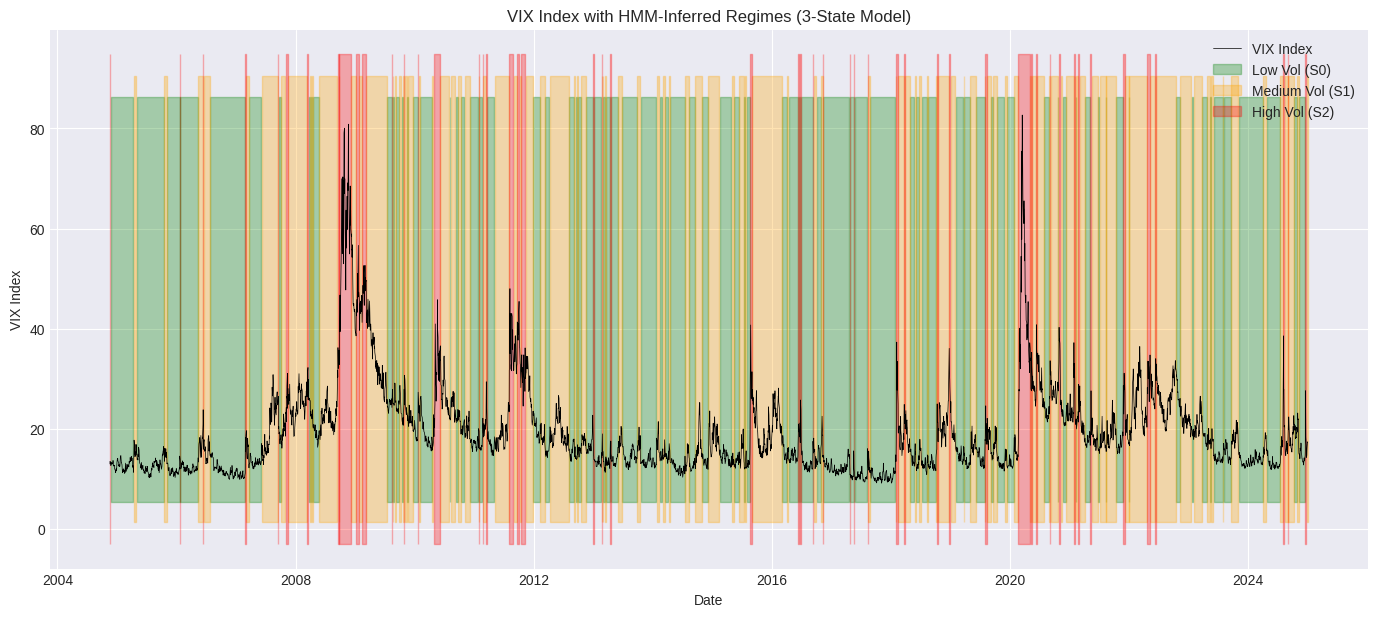

In [8]:
# Run the 3-state filter over the full dataset
filtered_probs_3, _, _ = hamilton_filter(y, mus_3, sigmas_3, P_3, pi_3)

# Run the Hamilton smoother to get smoothed state probabilities
smoothed_probs_3 = hamilton_smoother(filtered_probs_3, P_3)

# Get the most likely state (0, 1, or 2) from smoothed probabilities
regime_sequence = np.argmax(smoothed_probs_3, axis=1)

# Add the regime to our VIX data DataFrame
common_data['Regime'] = pd.Series(regime_sequence, index=returns_df.index)

# --- Plotting ---
plt.figure(figsize=(17, 7))
ax = plt.gca()

# Plot the VIX index
ax.plot(common_data.index, common_data['VIX'], color='black', lw=0.5, label='VIX Index')

# Define colors for the regimes
colors = ['green', 'orange', 'red']
regime_labels = ['Low Vol (S0)', 'Medium Vol (S1)', 'High Vol (S2)']

# Add color-coded background for each regime
for i in range(N_3):
    ax.fill_between(common_data.index,
                    ax.get_ylim()[0],
                    ax.get_ylim()[1],
                    where=(common_data['Regime'] == i),
                    color=colors[i],
                    alpha=0.3,
                    label=regime_labels[i])

ax.set_title('VIX Index with HMM-Inferred Regimes (3-State Model)')
ax.set_ylabel('VIX Index')
ax.set_xlabel('Date')
ax.legend()
plt.show()

## Step 3: State Selection and Interpretation

In this step, we will compare the 2-state and 3-state HMMs to select the best model. We will then analyze the financial characteristics of the chosen regimes to build our intuition.

### 3.1: Compare Candidate Models (AIC & BIC)

We'll use the Log-Likelihood (LL) from Step 2 and calculate the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) to compare the models.

- AIC = $2k - 2(LL)$
- BIC = $k \cdot \ln(T) - 2(LL)$

Where:

- k = number of estimated parameters.
- T = number of observations.

For our models, the number of parameters (k) is:

- 2-State (N=2): 7 parameters (2 $\mu$, 2 $\sigma$, 2 $P_{ii}$, 1 $\pi_i$)
- 3-State (N=3): 11 parameters (3 $\mu$, 3 $\sigma$, 3 $P_{ii}$, 2 $\pi_i$)

In [9]:
# --- Model Comparison ---

# T = Number of observations (from Step 1)
T = len(y)

# k = Number of parameters (from Step 2)
k_2_state = 7
k_3_state = 11

# Calculate AIC
aic_2 = 2 * k_2_state - 2 * ll_2
bic_2 = k_2_state * np.log(T) - 2 * ll_2

aic_3 = 2 * k_3_state - 2 * ll_3
bic_3 = k_3_state * np.log(T) - 2 * ll_3

# Create a comparison table
model_comp = pd.DataFrame({
    'Model': ['2-State HMM', '3-State HMM'],
    'Log-Likelihood': [ll_2, ll_3],
    'k': [k_2_state, k_3_state],
    'AIC': [aic_2, aic_3],
    'BIC': [bic_2, bic_3]
})

print("--- Model Comparison ---")
print(model_comp.to_markdown(index=False, floatfmt=".2f"))

--- Model Comparison ---
| Model       |   Log-Likelihood |   k |       AIC |       BIC |
|:------------|-----------------:|----:|----------:|----------:|
| 2-State HMM |       -139868.23 |   7 | 279750.46 | 279796.16 |
| 3-State HMM |         -8298.17 |  11 |  16618.34 |  16690.17 |


### 3.2: Select Preferred Model
Based on the table, the 3-State HMM is the clear winner. It has a significantly higher (less negative) Log-Likelihood and much lower AIC and BIC values, indicating a superior fit even after penalizing for its extra parameters.

We will proceed with the 3-State Model.

### 3.3: Analyze State-Conditional Returns
Now, let's analyze the average (mean) and volatility (std dev) of our assets (SPY, GLD, TLT) within each of the three regimes identified by the model.

This will tell us how the assets actually behave in "Low", "Medium", and "High" volatility states.


--- Annualized Mean Return by Regime ---
|                 |   SPY_logret |   GLD_logret |   TLT_logret |
|:----------------|-------------:|-------------:|-------------:|
| Low Vol (S0)    |       31.91% |        9.68% |       -1.98% |
| Medium Vol (S1) |        6.01% |        7.28% |        3.37% |
| High Vol (S2)   |     -108.73% |        7.09% |       33.85% |

--- Annualized Volatility by Regime ---
|                 |   SPY_logret |   GLD_logret |   TLT_logret |
|:----------------|-------------:|-------------:|-------------:|
| Low Vol (S0)    |        8.65% |       14.86% |       11.79% |
| Medium Vol (S1) |       18.35% |       17.28% |       15.11% |
| High Vol (S2)   |       47.48% |       30.26% |       25.77% |


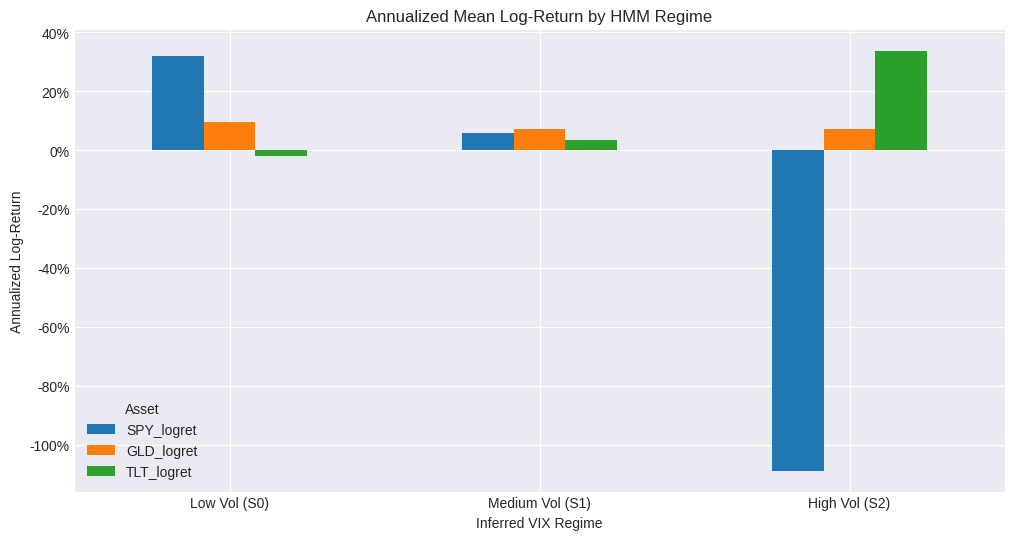

In [10]:
# 1. Merge regime data (from common_data) with returns data (from returns_df)
# We use an 'inner' join to ensure we only have trading days with valid returns and regimes.
data_with_regimes = pd.concat([
    common_data[['Regime']],
    returns_df[['SPY_logret', 'GLD_logret', 'TLT_logret']]
], axis=1, join='inner').dropna()

# 2. Group by regime and calculate mean and std dev
state_stats = data_with_regimes.groupby('Regime')[['SPY_logret', 'GLD_logret', 'TLT_logret']].agg(['mean', 'std'])

# 3. Annualize the statistics for easier interpretation
# Annualized Mean = mean_daily_log_ret * 252
# Annualized Vol = std_dev_daily_log_ret * sqrt(252)
state_means_ann = state_stats.loc[:, (slice(None), 'mean')].droplevel(1, axis=1) * 252
state_stds_ann = state_stats.loc[:, (slice(None), 'std')].droplevel(1, axis=1) * np.sqrt(252)

# Rename states for clarity
state_means_ann.index = ['Low Vol (S0)', 'Medium Vol (S1)', 'High Vol (S2)']
state_stds_ann.index = ['Low Vol (S0)', 'Medium Vol (S1)', 'High Vol (S2)']

print("\n--- Annualized Mean Return by Regime ---")
print(state_means_ann.to_markdown(floatfmt=".2%"))

print("\n--- Annualized Volatility by Regime ---")
print(state_stds_ann.to_markdown(floatfmt=".2%"))

# 4. Visualize the Mean Returns with a Bar Chart
state_means_ann.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Annualized Mean Log-Return by HMM Regime')
plt.ylabel('Annualized Log-Return')
plt.xlabel('Inferred VIX Regime')
plt.legend(title='Asset')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.show()

## Step 4: Designing the Rotation Strategy
### 4.1: Define the Rule-Based Allocation
We will use the state_means_ann DataFrame (annualized mean log-returns) from Step 3 to define our simple, rule-based policy.

The rule is: For each state, allocate 100% to the ETF with the highest annualized mean return.

In [11]:
# --- 4.1: Define the Rule-Based Allocation ---

# The 'state_means_ann' DataFrame is required from Step 3.3
print("--- Annualized Mean Return by Regime (from Step 3.3) ---")
print(state_means_ann.to_markdown(floatfmt=".2%"))

# Find the asset (column name) with the highest mean return for each regime (row)
best_asset_col = state_means_ann.idxmax(axis=1)

# Clean up the names (e.g., 'SPY_logret' -> 'SPY')
policy_map_strings = {
    'SPY_logret': 'SPY',
    'GLD_logret': 'GLD',
    'TLT_logret': 'TLT'
}
policy_action_series = best_asset_col.map(policy_map_strings)

# Create the policy_map for the backtest *before* changing the index
# This creates the correct map: {0: 'SPY', 1: 'GLD', 2: 'TLT'}
policy_map = policy_action_series.to_dict()

# Now, for display purposes, change the index
policy_action_series.index = ['State 0 (Low Vol)', 'State 1 (Medium Vol)', 'State 2 (High Vol)']
policy_action_series.name = "Allocation"
policy_action_series.index.name = "State"

# --- 4.2: Final State-Allocation Mapping Table ---
print("\n--- Final State -> Allocation Mapping (Policy) ---")
print(policy_action_series.to_markdown())

--- Annualized Mean Return by Regime (from Step 3.3) ---
|                 |   SPY_logret |   GLD_logret |   TLT_logret |
|:----------------|-------------:|-------------:|-------------:|
| Low Vol (S0)    |       31.91% |        9.68% |       -1.98% |
| Medium Vol (S1) |        6.01% |        7.28% |        3.37% |
| High Vol (S2)   |     -108.73% |        7.09% |       33.85% |

--- Final State -> Allocation Mapping (Policy) ---
| State                | Allocation   |
|:---------------------|:-------------|
| State 0 (Low Vol)    | SPY          |
| State 1 (Medium Vol) | GLD          |
| State 2 (High Vol)   | TLT          |


## Step 5: Backtesting and Evaluation


In [39]:
returns_df.head()

,SPY_logret,GLD_logret,TLT_logret,VIX_change
Date,,,,
2004-11-19,-0.011179,0.008973,-0.008012,0.520000
2004-11-22,0.004758,0.003789,0.005198,-0.530000
2004-11-23,0.001524,-0.004459,0.001240,-0.300000
2004-11-24,0.002367,0.006682,0.000000,0.050000
2004-11-26,-0.000760,0.005313,-0.006551,0.059999


In [43]:
common_data = common_data[['Regime']].dropna() # to have the same shape before merge
common_data.head()

Ticker,Regime
Date,
2004-11-19,2.0
2004-11-22,0.0
2004-11-23,0.0
2004-11-24,0.0
2004-11-26,0.0


In [46]:
# Merge and prepare data
data = pd.concat([common_data, returns_df], axis=1, join='inner')
data = data.sort_index()

In [50]:
print(data['Regime'].unique())
print(data['Regime_lag'].head(5))
policy_map

[2. 0. 1.]
Date
2004-11-19    <NA>
2004-11-22       2
2004-11-23       0
2004-11-24       0
2004-11-26       0
Name: Regime_lag, dtype: Int64


{'Low Vol (S0)': 'SPY', 'Medium Vol (S1)': 'GLD', 'High Vol (S2)': 'TLT'}

In [48]:
# Fix the mapping to numeric state keys
policy_map_fixed = {
    0: 'SPY',   # Low Vol (S0)
    1: 'GLD',   # Medium Vol (S1)
    2: 'TLT'    # High Vol (S2)
}

# Add 1-day execution lag
data['Regime_lag'] = data['Regime'].shift(1).astype('Int64')

In [34]:
# Vectorized assignment
data['Strategy_ret'] = np.nan
for state, asset in policy_map_fixed.items():
    col = asset + '_logret'
    mask = data['Regime_lag'] == state
    data.loc[mask, 'Strategy_ret'] = np.expm1(data.loc[mask, col])

data['Strategy_ret'] = data['Strategy_ret'].fillna(0.0)
data[['Regime_lag','Strategy_ret']].head(10)

,Regime_lag,Strategy_ret
Date,,
2004-11-19,<NA>,0.000000
2004-11-22,2,0.005211
2004-11-23,0,0.001525
2004-11-24,0,0.002370
2004-11-26,0,-0.000760
2004-11-29,0,-0.004563
2004-11-30,0,0.000679
2004-12-01,0,0.011367
2004-12-02,0,0.000839


In [58]:
# Apply allocation rule from Step 4
def pick_asset(row):
    state = row['Regime_lag']
    if pd.isna(state):
        return np.nan
    asset = policy_map_fixed.get(state)
    return asset

data['Asset_to_Hold'] = data.apply(pick_asset, axis=1)


In [59]:
# Compute daily strategy return (using lagged regime)
data['Strategy_ret'] = np.nan
for i, row in data.iterrows():
    asset = row['Asset_to_Hold']
    if asset == 'SPY':
        data.loc[i, 'Strategy_ret'] = np.exp(row['SPY_logret']) - 1
    elif asset == 'GLD':
        data.loc[i, 'Strategy_ret'] = np.exp(row['GLD_logret']) - 1
    elif asset == 'TLT':
        data.loc[i, 'Strategy_ret'] = np.exp(row['TLT_logret']) - 1
    else:
        data.loc[i, 'Strategy_ret'] = 0.0

In [60]:
# Equal-weight (monthly rebalance)
simple = np.expm1(data[['SPY_logret','GLD_logret','TLT_logret']])
ew_ret = []
w = np.array([1/3,1/3,1/3])
for i in range(len(simple)):
    if i>0 and simple.index[i].month != simple.index[i-1].month:
        w = np.array([1/3,1/3,1/3])     # rebalance monthly
    ew_ret.append(np.dot(w, simple.iloc[i]))
    w = w*(1+simple.iloc[i]); w = w/np.sum(w)
data['EqualWeight_ret'] = ew_ret

In [61]:
# Buy-and-hold SPY
data['SPY_BH_ret'] = np.expm1(data['SPY_logret'])

In [62]:
#Performance metrics helper
def perf_stats(series, freq=252):
    s = series.dropna()
    nav = (1+s).cumprod()
    ann_ret = (1+s).prod()**(freq/len(s)) - 1
    ann_vol = s.std()*np.sqrt(freq)
    sharpe = ann_ret/ann_vol if ann_vol>0 else np.nan
    dd = nav/nav.cummax() - 1
    return {
        'Cumulative Return': nav.iloc[-1]-1,
        'Annualized Return': ann_ret,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': dd.min()
    }

In [63]:
#Compute and display metrics
perf = {
    'Rotation': perf_stats(data['Strategy_ret']),
    'EqualWeight': perf_stats(data['EqualWeight_ret']),
    'SPY_BuyHold': perf_stats(data['SPY_BH_ret'])
}
perf_df = pd.DataFrame(perf).T
display(perf_df.round(4))

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Rotation,21.6158,0.1680,0.1479,1.1358,-0.2613
EqualWeight,3.8272,0.0815,0.0950,0.8583,-0.2304
SPY_BuyHold,6.2257,0.1035,0.1899,0.5449,-0.5519


<Figure size 1000x500 with 0 Axes>

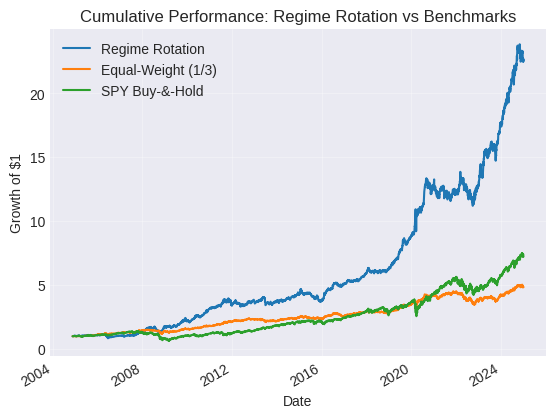

In [64]:
#Plot cumulative NAVs
plt.figure(figsize=(10,5))
nav = (1+data[['Strategy_ret','EqualWeight_ret','SPY_BH_ret']]).cumprod()
nav.columns = ['Regime Rotation','Equal-Weight (1/3)','SPY Buy-&-Hold']
nav.plot(title='Cumulative Performance: Regime Rotation vs Benchmarks')
plt.ylabel('Growth of $1')
plt.grid(alpha=0.3)
plt.show()

In [67]:
#Save summary
perf_df.to_csv('Step5_Performance_Summary.csv')
print("Performance summary saved to Step5_Performance_Summary.csv")

Performance summary saved to Step5_Performance_Summary.csv
